In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/Colon_cancer_project" # change this to your own path

RAW_TPM  = f"{BASE}/data_raw/ibd/GSE235236_TPM_matrix_with_symbols.csv"
RAW_META = f"{BASE}/data_raw/ibd/ibd_metadata.csv"

OUT_PROC = f"{BASE}/data_processed/ibd"
OUT_DE   = f"{BASE}/results/de/ibd"
OUT_FIG  = f"{BASE}/results/figures/ibd"

import os
os.makedirs(OUT_PROC, exist_ok=True)
os.makedirs(OUT_DE,   exist_ok=True)
os.makedirs(OUT_FIG,  exist_ok=True)

print("TPM:", RAW_TPM)
print("META:", RAW_META)

TPM: /content/drive/MyDrive/Colon_cancer_project/data_raw/ibd/GSE235236_TPM_matrix_with_symbols.csv
META: /content/drive/MyDrive/Colon_cancer_project/data_raw/ibd/ibd_metadata.csv


In [ ]:
import pandas as pd, numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt


In [ ]:
tpm = pd.read_csv(RAW_TPM)
print("Raw TPM shape:", tpm.shape)
print("First columns:", list(tpm.columns[:6]))

# detect gene column, add gene column if its not in the list
gene_col = None
for c in tpm.columns[:5]:
    if str(c).lower() in ["gene","symbol","hugo_symbol","gene_symbol","genesymbol","gene_id"]:
        gene_col = c
        break
if gene_col is None:
    gene_col = tpm.columns[0]
print("Using gene column:", gene_col)

tpm = tpm.dropna(subset=[gene_col])
tpm[gene_col] = tpm[gene_col].astype(str).str.strip()
tpm = tpm.set_index(gene_col)

tpm = tpm.apply(pd.to_numeric, errors="coerce")
display(tpm.head())

Raw TPM shape: (58278, 57)
First columns: ['gene_id', 'GSM7497463', 'GSM7497464', 'GSM7497465', 'GSM7497466', 'GSM7497467']
Using gene column: gene_id


,GSM7497463,GSM7497464,GSM7497465,GSM7497466,GSM7497467,GSM7497468,GSM7497469,GSM7497470,GSM7497471,GSM7497472,...,GSM7497509,GSM7497510,GSM7497511,GSM7497512,GSM7497513,GSM7497514,GSM7497515,GSM7497516,GSM7497517,GSM7497518
gene_id,,,,,,,,,,,,,,,,,,,,,
TSPAN6,31.02,18.74,34.28,47.06,38.40,26.14,59.04,8.15,17.22,45.00,...,49.22,54.06,36.50,53.41,56.33,73.22,59.29,70.34,34.34,43.48
TNMD,0.46,0.10,0.16,0.82,0.70,0.19,0.60,0.03,0.57,0.73,...,0.84,0.44,1.00,0.61,1.04,1.16,0.74,0.19,0.20,0.43
DPM1,37.82,35.16,34.50,28.92,34.40,28.84,28.41,49.76,35.75,27.71,...,35.50,32.59,29.95,37.50,33.88,64.20,46.39,34.47,48.93,44.56
SCYL3,5.68,4.63,5.03,4.50,4.53,5.09,5.94,2.39,4.43,2.91,...,6.68,6.57,6.19,7.61,6.77,5.07,8.46,8.27,7.36,8.21
FIRRM,1.42,2.92,1.48,1.97,2.96,2.23,1.87,2.16,2.53,2.23,...,1.68,1.54,1.64,1.63,1.65,5.23,4.56,1.47,4.28,4.84


Total NA: 0
Duplicate genes: 1085
Clean TPM shape: (57193, 56)


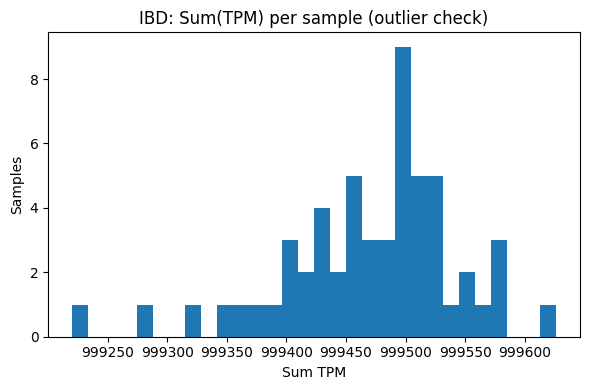

Saved -> /content/drive/MyDrive/Colon_cancer_project/data_processed/ibd/ibd_tpm_clean.csv


In [ ]:
print("Total NA:", int(tpm.isna().sum().sum()))
tpm = tpm.fillna(0)

dup = int(tpm.index.duplicated().sum())
print("Duplicate genes:", dup)
if dup:
    tpm = tpm.groupby(tpm.index).mean()

print("Clean TPM shape:", tpm.shape)

# outlier check
sums = tpm.sum(axis=0)
plt.figure(figsize=(6,4))
plt.hist(sums, bins=30)
plt.title("IBD: Sum(TPM) per sample (outlier check)")
plt.xlabel("Sum TPM"); plt.ylabel("Samples")
plt.tight_layout(); plt.show()

tpm.to_csv(f"{OUT_PROC}/ibd_tpm_clean.csv")
print("Saved ->", f"{OUT_PROC}/ibd_tpm_clean.csv")

In [ ]:
meta = pd.read_csv(RAW_META)
display(meta.head())

need = {"sample_id","group"}
missing = need - set(meta.columns)
if missing:
    raise ValueError(f"Metadata missing columns: {missing}")

meta["sample_id"] = meta["sample_id"].astype(str).str.strip()
meta["group"]     = meta["group"].astype(str).str.strip()

tpm_cols  = pd.Index(tpm.columns.astype(str).str.strip())
meta_ids  = pd.Index(meta["sample_id"].astype(str).str.strip())
overlap   = tpm_cols.intersection(meta_ids)

print(f"Overlap samples: {len(overlap)} / TPM={tpm.shape[1]} / META={meta.shape[0]}")
if len(overlap) < 10:
    print(" Overlap is LOW. Fix sample_id in metadata to match TPM column names exactly.")

tpm  = tpm.loc[:, overlap]
meta = meta.set_index("sample_id").loc[overlap].reset_index()

print("Final TPM:", tpm.shape)
print("Final META:", meta.shape)

meta.to_csv(f"{OUT_PROC}/ibd_metadata_clean.csv", index=False)
print("Saved ->", f"{OUT_PROC}/ibd_metadata_clean.csv")

,sample_id,gender,group,tissue location,disease type,age,sample_info
0,GSM7497463,male,CD,Sigmoid colon,Colonic,33,Bulk 9
1,GSM7497464,female,UC,sigmoid,Pancolitis,57,Bulk 31
2,GSM7497465,male,UC,sigmoid,Pancolitis,55,Bulk 40
3,GSM7497466,Male,CD,Ascending colon,Ileocolonic,35,Bulk 16
4,GSM7497467,Male,CD,Descending colon,Colonic,22,Bulk 20


Overlap samples: 56 / TPM=56 / META=56
Final TPM: (57193, 56)
Final META: (56, 7)
Saved -> /content/drive/MyDrive/Colon_cancer_project/data_processed/ibd/ibd_metadata_clean.csv


In [ ]:
expr_log = np.log2(tpm + 1)
expr_log.to_csv(f"{OUT_PROC}/ibd_log2_tpm.csv")
print("Saved ->", f"{OUT_PROC}/ibd_log2_tpm.csv")

Saved -> /content/drive/MyDrive/Colon_cancer_project/data_processed/ibd/ibd_log2_tpm.csv


In [ ]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def run_deg_welch_safe(expr_log_df, meta_df, group_col="group",
                       case_labels=("UC","CD"), control_label="Control",
                       min_samples_per_group=3, min_var=1e-8):
    """
    Robust DEG for TPM/log data using Welch t-test.
    - case_labels: groups to combine into "IBD" (UC+CD)
    - control_label: Control group label
    """
    # ---- define group membership ----
    g = meta_df[group_col].astype(str).values
    case_mask = np.isin(g, list(case_labels))
    ctrl_mask = (g == control_label)

    n_case = int(case_mask.sum())
    n_ctrl = int(ctrl_mask.sum())

    print(f"Case (IBD={case_labels}) n={n_case} | Control n={n_ctrl}")

    if n_case < min_samples_per_group or n_ctrl < min_samples_per_group:
        raise ValueError("Too few samples in one group. Check metadata labels.")

    X_case = expr_log_df.loc[:, case_mask]
    X_ctrl = expr_log_df.loc[:, ctrl_mask]

    # ---- compute means + logFC ----
    mean_case = X_case.mean(axis=1)
    mean_ctrl = X_ctrl.mean(axis=1)
    logFC = mean_case - mean_ctrl

    # ---- filter genes with near-zero variance in BOTH groups ----
    var_case = X_case.var(axis=1)
    var_ctrl = X_ctrl.var(axis=1)
    valid_var = (var_case > min_var) | (var_ctrl > min_var)

    # ---- Welch t-test gene-wise (safe) ----
    pvals = np.full(expr_log_df.shape[0], np.nan, dtype=float)

    idx = np.where(valid_var.values)[0]
    for i in idx:
        pvals[i] = ttest_ind(
            X_case.iloc[i, :],
            X_ctrl.iloc[i, :],
            equal_var=False,
            nan_policy="omit"
        ).pvalue

    # ---- BH-FDR only on valid p-values ----
    padj = np.ones_like(pvals, dtype=float)  # default FDR=1
    valid_p = np.isfinite(pvals)

    if valid_p.sum() > 0:
        padj[valid_p] = multipletests(pvals[valid_p], method="fdr_bh")[1]

    out = pd.DataFrame({
        "gene": expr_log_df.index.astype(str),
        "mean_IBD": mean_case.values,
        "mean_Control": mean_ctrl.values,
        "logFC_IBD_minus_Control": logFC.values,
        "pval": pvals,
        "padj_fdr": padj,
        "var_IBD": var_case.values,
        "var_Control": var_ctrl.values,
        "valid_var": valid_var.values
    }).sort_values(["padj_fdr", "pval"], ascending=[True, True])

    return out

In [ ]:
# expr_log: genes x samples (log2(TPM+1))
# meta: aligned metadata (same sample order)

deg_ibd = run_deg_welch_safe(
    expr_log_df=expr_log,
    meta_df=meta,
    group_col="group",
    case_labels=("UC","CD"),
    control_label="Control"
)

display(deg_ibd.head(15))

deg_ibd.to_csv(f"{OUT_DE}/IBD_DEG_IBD_vs_Control.csv", index=False)
print("Saved ->", f"{OUT_DE}/IBD_DEG_IBD_vs_Control.csv")


Case (IBD=('UC', 'CD')) n=48 | Control n=8


,gene,mean_IBD,mean_Control,logFC_IBD_minus_Control,pval,padj_fdr,var_IBD,var_Control,valid_var
5727,CTXN1,0.489287,0.039712,0.449576,2.501936e-12,1.153092e-07,0.094302,0.003835,True
40643,PLPBP,4.822146,5.318890,-0.496744,1.268496e-11,2.923121e-07,0.084293,0.007565,True
5484,CS,6.525292,7.040912,-0.515620,7.534646e-11,1.157523e-06,0.109758,0.009157,True
24645,HADHB,6.141195,6.701227,-0.560032,1.411664e-10,1.626520e-06,0.115514,0.011828,True
41607,PRR7,1.124470,0.209994,0.914476,2.812464e-10,2.356714e-06,0.224133,0.033103,True
55756,WDR20,3.368291,3.675910,-0.307618,3.068105e-10,2.356714e-06,0.048240,0.003420,True
3788,CD164,7.670364,8.109978,-0.439615,4.422712e-10,2.573611e-06,0.120798,0.005791,True
23920,GOLPH3L,4.928584,5.399781,-0.471197,4.525243e-10,2.573611e-06,0.104956,0.008798,True
40341,PIGU,3.727202,4.266289,-0.539087,5.025711e-10,2.573611e-06,0.090687,0.012295,True
49569,SH3KBP1,5.219451,5.611793,-0.392342,6.168869e-10,2.694198e-06,0.109349,0.003536,True


Saved -> /content/drive/MyDrive/Colon_cancer_project/results/de/ibd/IBD_DEG_IBD_vs_Control.csv


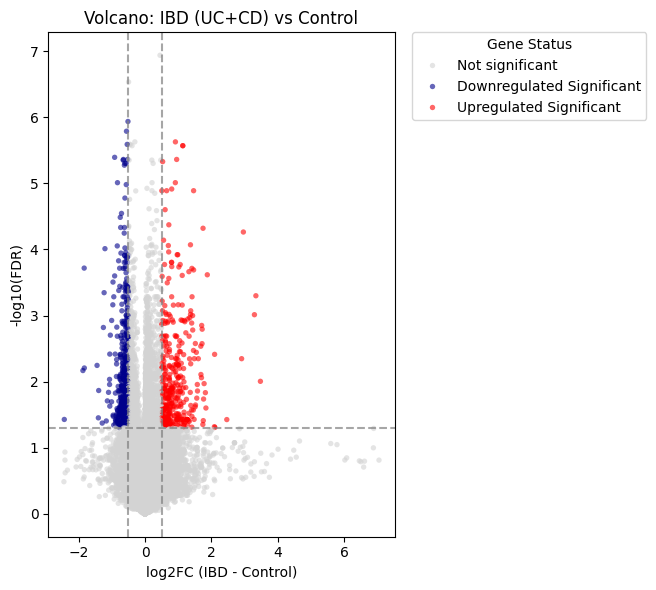

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# deg_ibd must contain: logFC_IBD_minus_Control, padj_fdr
df = deg_ibd.copy()

# safe -log10(FDR)
df["neglog10_fdr"] = -np.log10(df["padj_fdr"].astype(float) + 1e-300)

xcol = "logFC_IBD_minus_Control"

# Define thresholds
logfc_threshold = 0.5
padj_threshold = 0.05

# Categorize genes
df['expression_status'] = 'Not significant'
df.loc[(df[xcol] > logfc_threshold) & (df['padj_fdr'] < padj_threshold), 'expression_status'] = 'Upregulated Significant'
df.loc[(df[xcol] < -logfc_threshold) & (df['padj_fdr'] < padj_threshold), 'expression_status'] = 'Downregulated Significant'

# Define colors for categories
color_map = {
    'Upregulated Significant': 'red',
    'Downregulated Significant': 'darkblue',
    'Not significant': 'lightgrey'
}

plt.figure(figsize=(8, 6))

# Plot points with assigned colors
sns.scatterplot(
    data=df,
    x=xcol,
    y="neglog10_fdr",
    hue='expression_status',
    palette=color_map,
    s=15, # marker size
    alpha=0.6,
    linewidth=0 # remove borders for scatter points
)

# Add thresholds
plt.axvline(logfc_threshold, linestyle="--", color='grey', alpha=0.7)
plt.axvline(-logfc_threshold, linestyle="--", color='grey', alpha=0.7)
plt.axhline(-np.log10(padj_threshold), linestyle="--", color='grey', alpha=0.7)

plt.title("Volcano: IBD (UC+CD) vs Control")
plt.xlabel("log2FC (IBD - Control)")
plt.ylabel("-log10(FDR)")

# Place legend outside the plot area
plt.legend(title='Gene Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

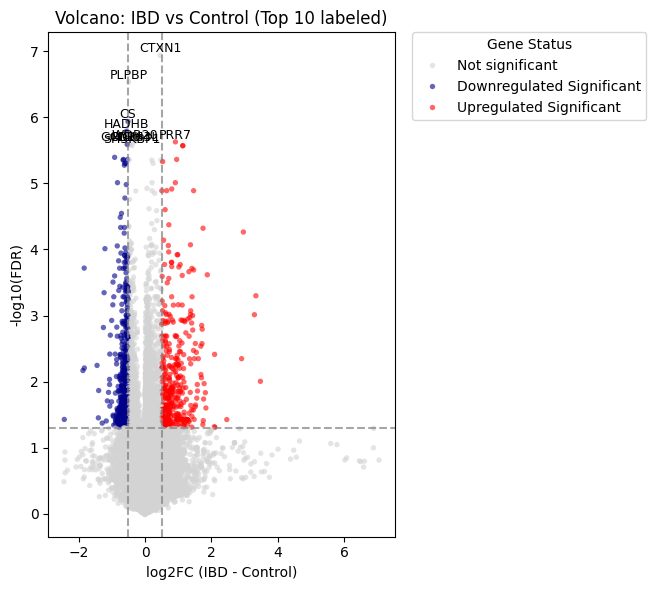

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# deg_ibd must contain: logFC_IBD_minus_Control, padj_fdr
df = deg_ibd.copy()

# safe -log10(FDR)
df["neglog10_fdr"] = -np.log10(df["padj_fdr"].astype(float) + 1e-300)

xcol = "logFC_IBD_minus_Control"

# Define thresholds
logfc_threshold = 0.5
padj_threshold = 0.05

# Categorize genes
df['expression_status'] = 'Not significant'
df.loc[(df[xcol] > logfc_threshold) & (df['padj_fdr'] < padj_threshold), 'expression_status'] = 'Upregulated Significant'
df.loc[(df[xcol] < -logfc_threshold) & (df['padj_fdr'] < padj_threshold), 'expression_status'] = 'Downregulated Significant'

# Define colors for categories
color_map = {
    'Upregulated Significant': 'red',
    'Downregulated Significant': 'darkblue',
    'Not significant': 'lightgrey'
}

plt.figure(figsize=(8, 6))

# Plot points with assigned colors
sns.scatterplot(
    data=df,
    x=xcol,
    y="neglog10_fdr",
    hue='expression_status',
    palette=color_map,
    s=15, # marker size
    alpha=0.6,
    linewidth=0 # remove borders for scatter points
)

# Add thresholds
plt.axvline(logfc_threshold, linestyle="--", color='grey', alpha=0.7)
plt.axvline(-logfc_threshold, linestyle="--", color='grey', alpha=0.7)
plt.axhline(-np.log10(padj_threshold), linestyle="--", color='grey', alpha=0.7)

# Identify top 10 genes for labeling (already sorted by padj_fdr in deg_ibd)
top_genes_to_label = df.sort_values("padj_fdr").head(10)

# Add labels for top genes
for _, row in top_genes_to_label.iterrows():
    plt.text(
        row[xcol],
        row["neglog10_fdr"],
        row["gene"],
        fontsize=9,
        ha='center',
        va='bottom',
        color='black' # Label color can be black for readability over colored points
    )

plt.title("Volcano: IBD vs Control (Top 10 labeled)")
plt.xlabel("log2FC (IBD - Control)")
plt.ylabel("-log10(FDR)")

# Place legend outside the plot area
plt.legend(title='Gene Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
plt.show()

In [ ]:
import seaborn as sns

# Filter for significant genes (padj_fdr < 0.05)
significant_genes = deg_ibd[deg_ibd['padj_fdr'] < 0.05]

# Get top 20 upregulated genes (positive logFC)
top20_up = significant_genes[significant_genes['logFC_IBD_minus_Control'] > 0]
if len(top20_up) > 20:
    top20_up = top20_up.sort_values(by='logFC_IBD_minus_Control', ascending=False).head(20)
else:
    print(f"Warning: Less than 20 upregulated genes found ({len(top20_up)}). Using all significant upregulated genes.")

# Get top 20 downregulated genes (negative logFC)
top20_down = significant_genes[significant_genes['logFC_IBD_minus_Control'] < 0]
if len(top20_down) > 20:
    top20_down = top20_down.sort_values(by='logFC_IBD_minus_Control', ascending=True).head(20)
else:
    print(f"Warning: Less than 20 downregulated genes found ({len(top20_down)}). Using all significant downregulated genes.")

# Combine the gene lists
top_genes = pd.concat([top20_up, top20_down])['gene'].tolist()

print(f"Number of top upregulated genes: {len(top20_up)}")
print(f"Number of top downregulated genes: {len(top20_down)}")
print(f"Total genes for heatmap: {len(top_genes)}")


Number of top upregulated genes: 20
Number of top downregulated genes: 20
Total genes for heatmap: 40


# The heatmap in the next code cell won't be used, check the updated heatmap in the end

Saved heatmap -> /content/drive/MyDrive/Colon_cancer_project/results/figures/ibd/IBD_heatmap_top_genes.png


<Figure size 1000x1200 with 0 Axes>

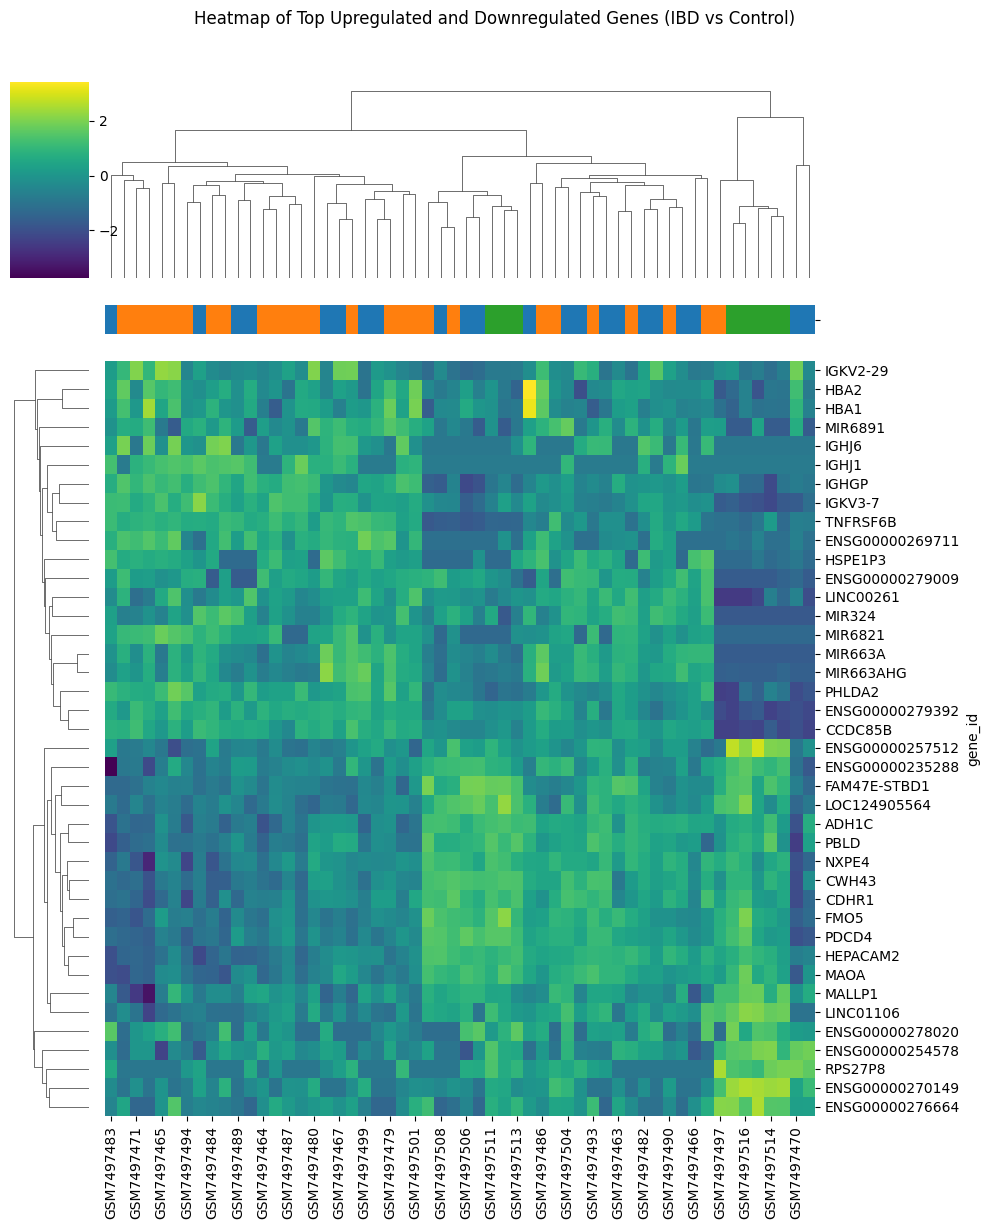

In [ ]:
# Extract expression data for the selected genes
heatmap_data = expr_log.loc[top_genes, :]

# Prepare annotation for samples
# Ensure meta_df is indexed by sample_id and has 'group' column
annotation_df = meta.set_index('index').loc[heatmap_data.columns]['group'].to_frame()
annotation_df.columns = ['Group']

# Define color palette for the groups
unique_groups = annotation_df['Group'].unique()
if len(unique_groups) <= 10:
    group_colors = dict(zip(unique_groups, sns.color_palette('tab10', n_colors=len(unique_groups))))
else:
    group_colors = dict(zip(unique_groups, sns.color_palette('hsv', n_colors=len(unique_groups))))

annotation_colors = {'Group': group_colors}

# Generate the heatmap
plt.figure(figsize=(10, 12))
sns.clustermap(heatmap_data,
               cmap='viridis', # Choose a suitable colormap
               z_score=0,      # Scale rows to mean 0, variance 1
               col_colors=annotation_df.apply(lambda x: annotation_colors['Group'][x['Group']], axis=1),
               cbar_pos=(0.02, 0.8, 0.03, 0.15),
               dendrogram_ratio=(.1, .2),
               figsize=(10, 12))

plt.suptitle('Heatmap of Top Upregulated and Downregulated Genes (IBD vs Control)', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/IBD_heatmap_top_genes.png", dpi=300, bbox_inches='tight')
print(f"Saved heatmap -> {OUT_FIG}/IBD_heatmap_top_genes.png")
plt.show()


# Task
Identify the top 5 most upregulated and top 5 most downregulated genes from the `deg_ibd` DataFrame, filtering for genes with an adjusted p-value (FDR) less than 0.05. Then, for each of these 10 genes, generate violin plots showing the distribution of log2(TPM+1) expression values between the IBD (UC+CD) and Control groups. Save these plots to the `OUT_FIG` directory and finally summarize the insights gained from visualizing the expression of these top differentially expressed genes.

## Identify Top 10 Genes

### Subtask:
From the `deg_ibd` DataFrame, identify the top 5 most upregulated and top 5 most downregulated genes based on logFC and adjusted p-value (FDR < 0.05). This will result in a list of 10 genes.


**Reasoning**:
The first instruction is to filter the `deg_ibd` DataFrame for significant genes based on `padj_fdr < 0.05`. This filtered DataFrame will be used for identifying top upregulated and downregulated genes.



In [ ]:
significant_genes_filtered = deg_ibd[deg_ibd['padj_fdr'] < 0.05]
print(f"Number of significant genes (padj_fdr < 0.05): {len(significant_genes_filtered)}")

Number of significant genes (padj_fdr < 0.05): 2848


**Reasoning**:
Following the instructions, I will now identify the top 5 most upregulated genes from the `significant_genes_filtered` DataFrame by sorting based on logFC in descending order.



In [ ]:
top5_upregulated_genes = significant_genes_filtered.sort_values(by='logFC_IBD_minus_Control', ascending=False)['gene'].head(5).tolist()
print(f"Top 5 Upregulated Genes: {top5_upregulated_genes}")

Top 5 Upregulated Genes: ['IGHGP', 'IGHJ6', 'MIR663A', 'IGHJ1', 'TNFRSF6B']


**Reasoning**:
Following the instructions, I will now identify the top 5 most downregulated genes from the `significant_genes_filtered` DataFrame by sorting based on logFC in ascending order.



In [ ]:
top5_downregulated_genes = significant_genes_filtered.sort_values(by='logFC_IBD_minus_Control', ascending=True)['gene'].head(5).tolist()
print(f"Top 5 Downregulated Genes: {top5_downregulated_genes}")

Top 5 Downregulated Genes: ['ENSG00000270149', 'ENSG00000276664', 'RPS27P8', 'ADH1C', 'CWH43']


**Reasoning**:
As per the instructions, I need to combine the lists of top 5 upregulated and top 5 downregulated genes into a single list named `top_10_genes_for_plotting`.



In [ ]:
top_10_genes_for_plotting = top5_upregulated_genes + top5_downregulated_genes
print(f"Top 10 Genes for Plotting: {top_10_genes_for_plotting}")

Top 10 Genes for Plotting: ['IGHGP', 'IGHJ6', 'MIR663A', 'IGHJ1', 'TNFRSF6B', 'ENSG00000270149', 'ENSG00000276664', 'RPS27P8', 'ADH1C', 'CWH43']


**Reasoning**:
Now that the top 10 genes have been identified, I will prepare the data for plotting. This involves creating a combined DataFrame of the log-transformed expression data (`expr_log`) for these genes and the sample metadata (`meta`) to facilitate plotting by group.



In [ ]:
genes_to_plot_expr = expr_log.loc[top_10_genes_for_plotting].T.reset_index()
genes_to_plot_expr = genes_to_plot_expr.rename(columns={'index': 'sample_id'})

# Prepare metadata to merge, ensuring 'sample_id' is the key
meta_for_plot = meta[['index', 'group']].rename(columns={'index': 'sample_id'})

# Merge expression data with metadata
plot_data = pd.merge(genes_to_plot_expr, meta_for_plot, on='sample_id', how='left')

# Melt the DataFrame to a long format suitable for seaborn plotting
plot_data_melted = plot_data.melt(id_vars=['sample_id', 'group'], var_name='gene', value_name='expression')

print("Prepared data for plotting (first 5 rows):")
display(plot_data_melted.head())

Prepared data for plotting (first 5 rows):


,sample_id,group,gene,expression
0,GSM7497463,CD,IGHGP,8.245933
1,GSM7497464,UC,IGHGP,8.568868
2,GSM7497465,UC,IGHGP,9.261766
3,GSM7497466,CD,IGHGP,3.648465
4,GSM7497467,CD,IGHGP,5.340562


# **These violin plots won't be used, please see the next code cell**:
Now that the data is prepared in a melted format, I will generate individual violin plots for each of the top 10 genes. Each plot will show the distribution of log2(TPM+1) expression values across the different groups (IBD and Control), allowing for visual comparison and assessment of differential expression. I will also save each plot to the `OUT_FIG` directory.



/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


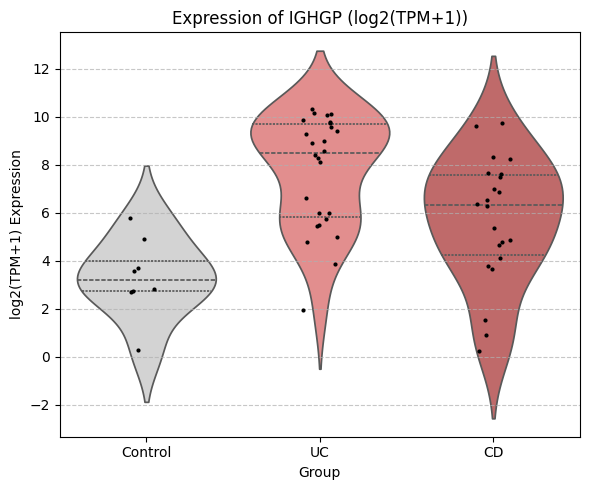

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


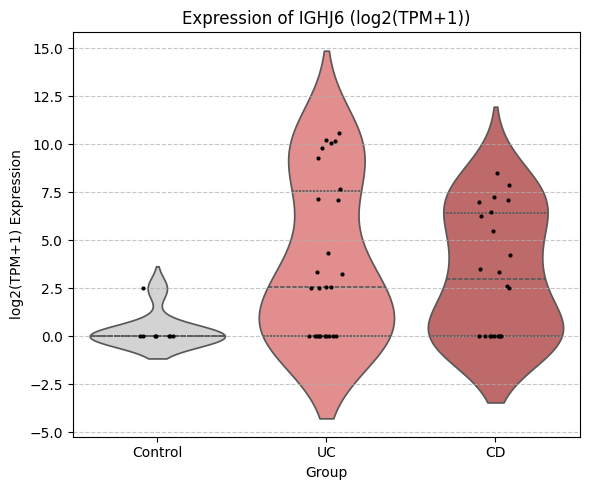

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


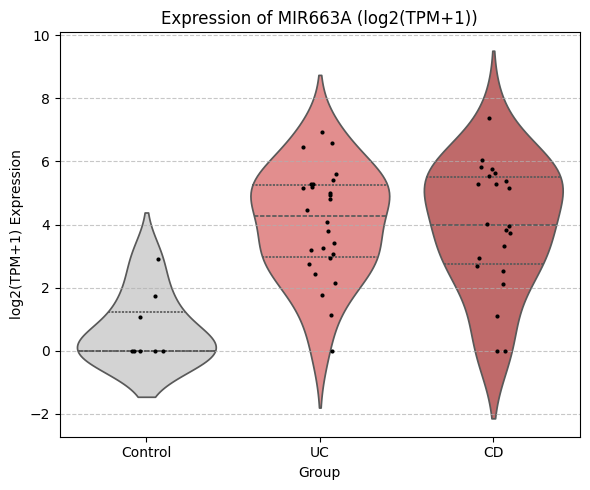

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


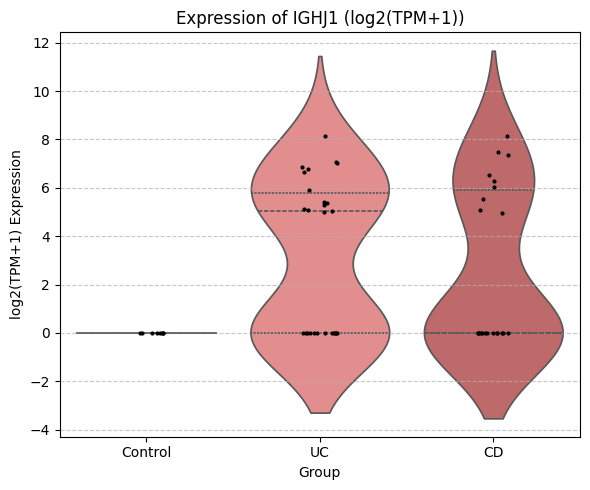

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


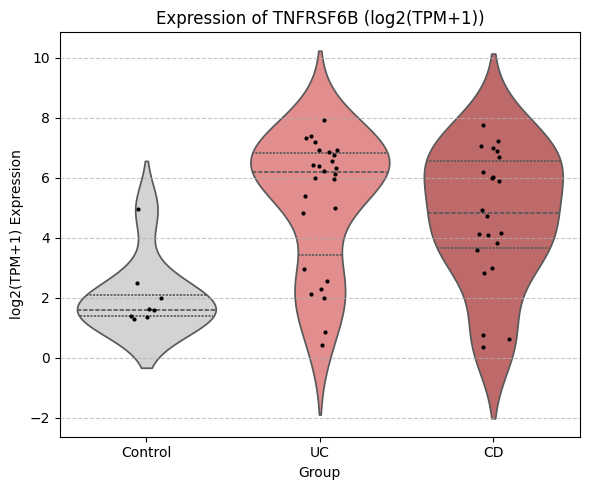

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


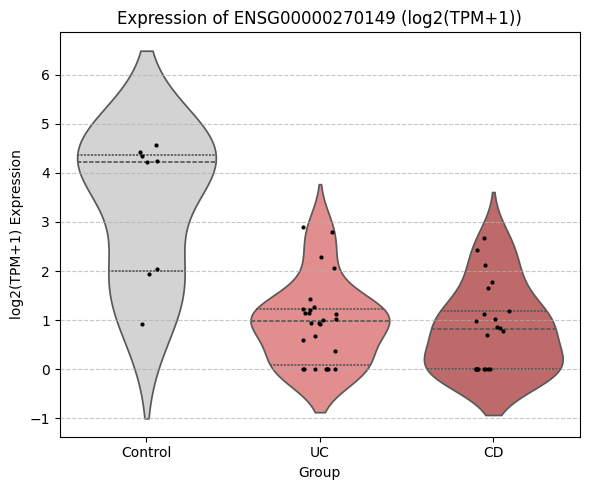

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


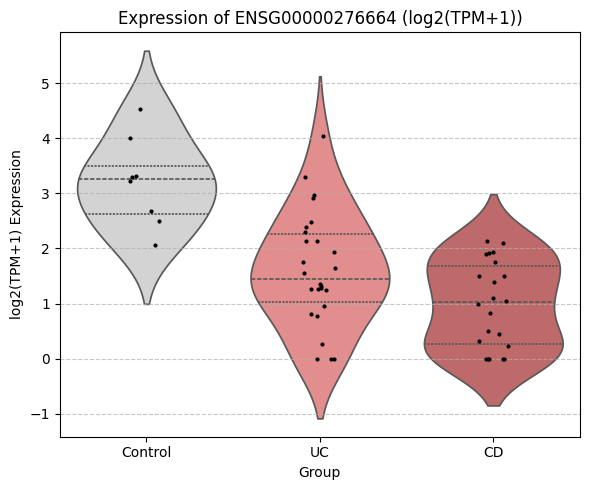

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


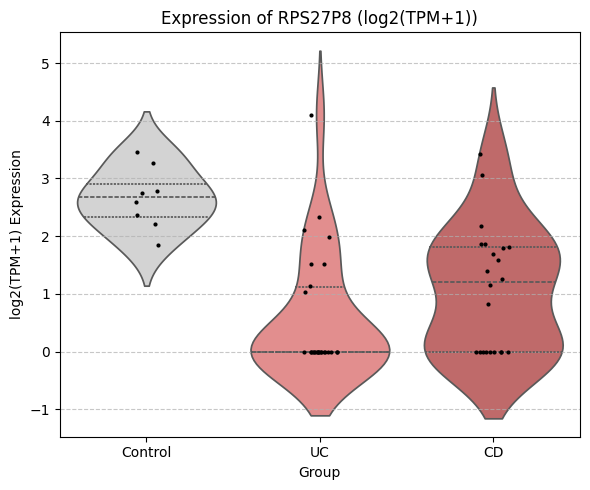

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


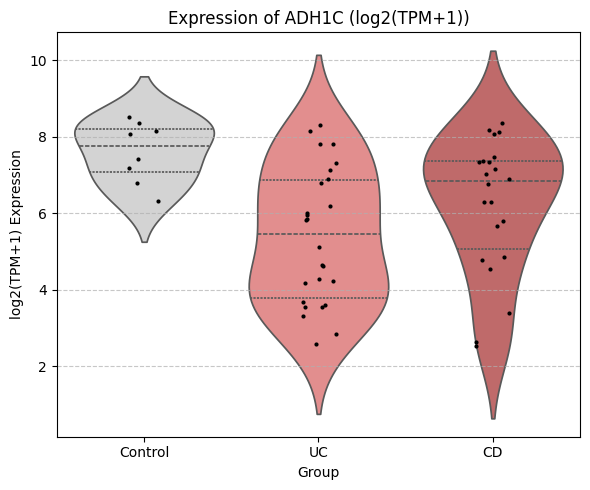

/tmp/ipython-input-1510421256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],


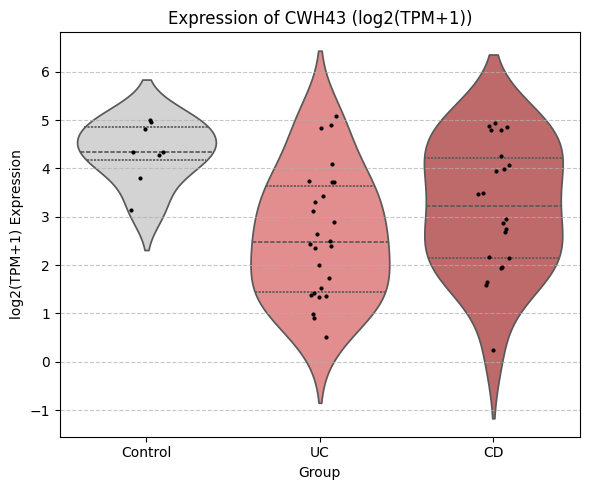

Violin plots generated and saved for each of the top 10 differentially expressed genes.


In [ ]:
unique_groups = plot_data_melted['group'].unique()
# Reorder groups to have Control first, then UC, then CD for consistent plotting
group_order = ['Control', 'UC', 'CD']
# Ensure all unique groups are in the specified order, adding any missing ones at the end
actual_group_order = [g for g in group_order if g in unique_groups] + [g for g in unique_groups if g not in group_order]

for gene in top_10_genes_for_plotting:
    plt.figure(figsize=(6, 5))
    sns.violinplot(data=plot_data_melted[plot_data_melted['gene'] == gene],
                   x='group', y='expression', order=actual_group_order, inner='quartile', palette={'Control': 'lightgray', 'UC': 'lightcoral', 'CD': 'indianred'})

    # Add individual data points to show sample distribution
    sns.stripplot(data=plot_data_melted[plot_data_melted['gene'] == gene],
                  x='group', y='expression', order=actual_group_order, color='black', size=3, jitter=True)

    plt.title(f'Expression of {gene} (log2(TPM+1))')
    plt.xlabel('Group')
    plt.ylabel('log2(TPM+1) Expression')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{OUT_FIG}/{gene}_violin_plot.png", dpi=300)
    plt.show()

print("Violin plots generated and saved for each of the top 10 differentially expressed genes.")

**Reasoning (Final violin plots)**:
The previous code generated `FutureWarning` messages from seaborn regarding the use of `palette` with `x` instead of `hue`. To resolve this and align with seaborn's best practices, I will modify the `sns.violinplot` call to use `hue='group'` and set `legend=False`, while keeping `x='group'` for proper positioning. I will also remove the `palette` argument from `violinplot` and instead set a custom palette using the `group_colors` dictionary.



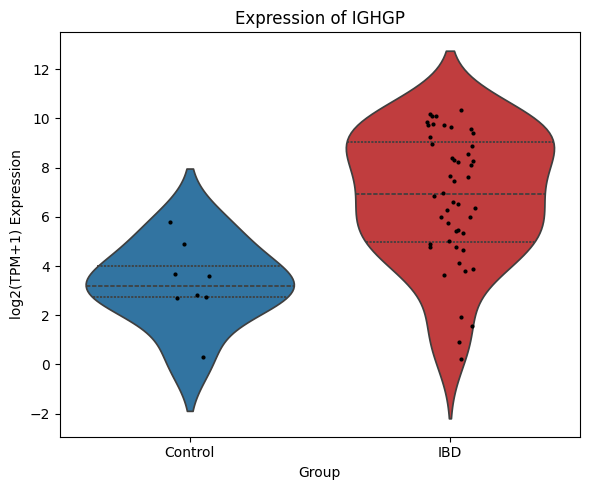

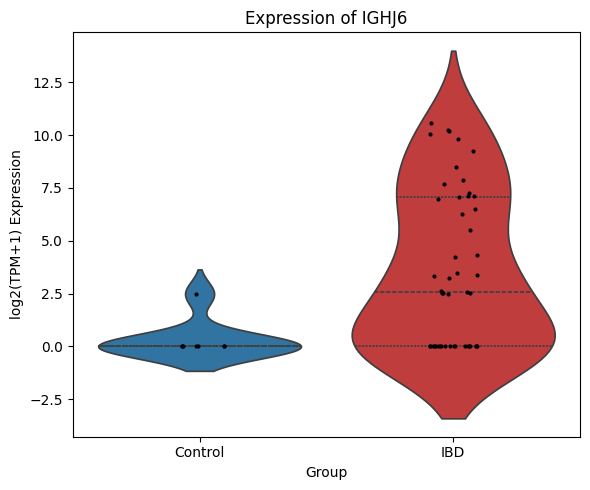

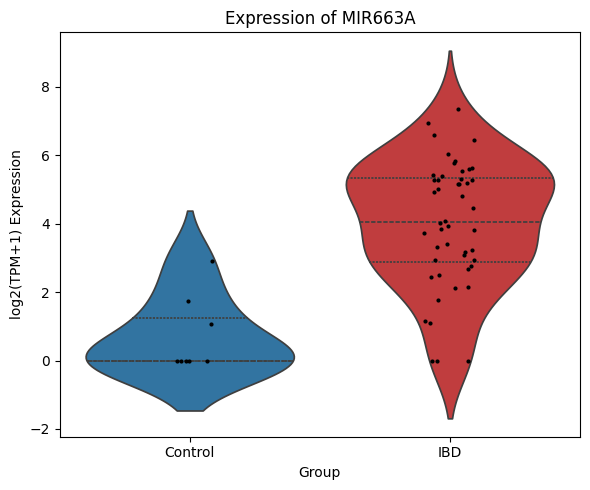

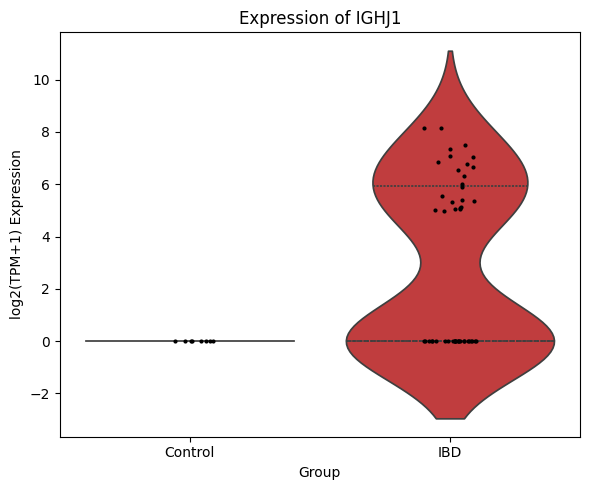

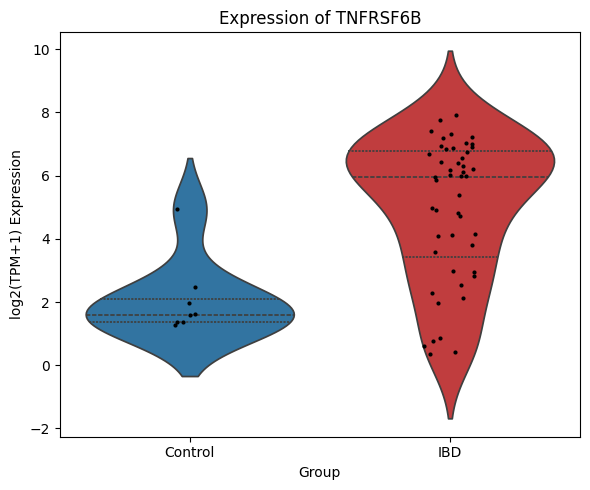

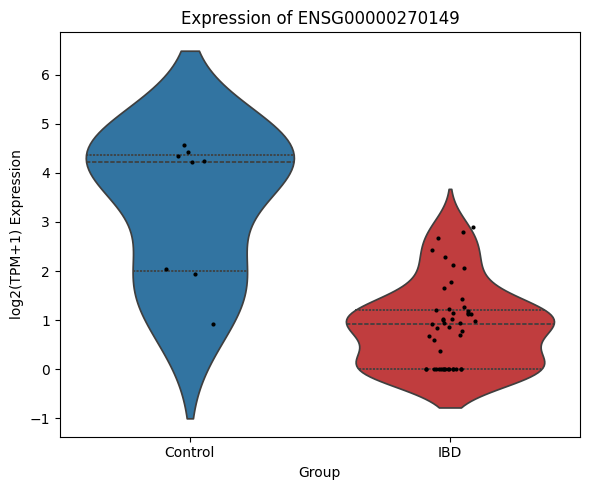

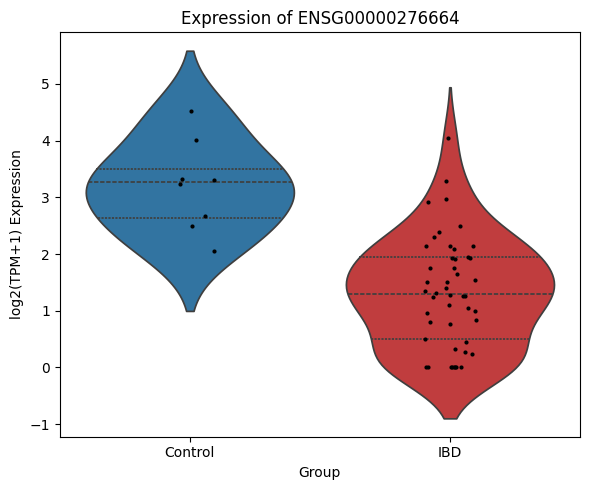

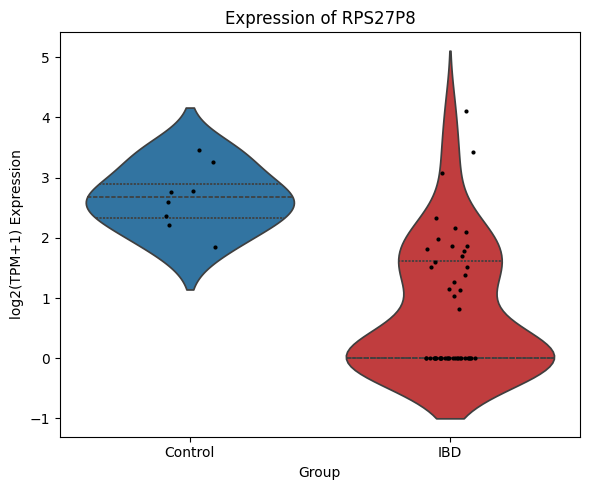

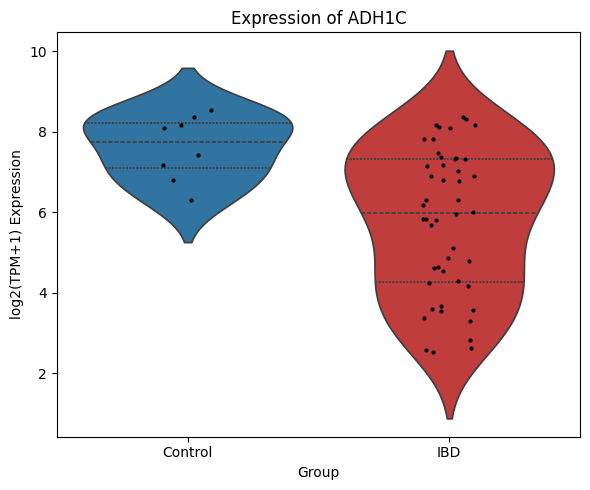

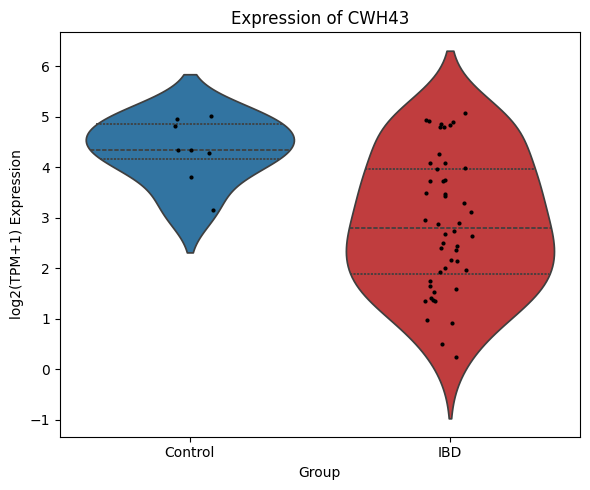

Violin plots generated and saved for each of the top 10 differentially expressed genes (IBD vs Control).


In [ ]:
# Create a copy of the melted DataFrame to modify groups for this specific plot
plot_data_melted_combined = plot_data_melted.copy()
plot_data_melted_combined['group'] = plot_data_melted_combined['group'].replace(['UC', 'CD'], 'IBD')

# Define the new order for groups
actual_group_order_combined = ['Control', 'IBD']

# Define a new, brighter color palette for the combined groups
# Using a color palette that contrasts well, complementing the 'viridis' heatmap if desired.
# 'Paired' or 'viridis' can be good choices. Let's use a distinct set from 'tab10'
combined_group_colors = {'Control': sns.color_palette('tab10')[0], 'IBD': sns.color_palette('tab10')[3]}

for gene in top_10_genes_for_plotting:
    plt.figure(figsize=(6, 5))
    sns.violinplot(data=plot_data_melted_combined[plot_data_melted_combined['gene'] == gene],
                   x='group', y='expression', hue='group', order=actual_group_order_combined,
                   inner='quartile', palette=combined_group_colors, legend=False)

    # Add individual data points to show sample distribution
    sns.stripplot(data=plot_data_melted_combined[plot_data_melted_combined['gene'] == gene],
                  x='group', y='expression', order=actual_group_order_combined, color='black', size=3, jitter=True)

    # Remove '(log2(TPM+1))' from the title
    plt.title(f'Expression of {gene}')
    plt.xlabel('Group')
    plt.ylabel('log2(TPM+1) Expression')

    # Remove gridlines
    # plt.grid(axis='y', linestyle='--', alpha=0.7) # Commented out to remove gridlines

    plt.tight_layout()
    plt.savefig(f"{OUT_FIG}/{gene}_violin_plot_combined.png", dpi=300)
    plt.show()

print("Violin plots generated and saved for each of the top 10 differentially expressed genes (IBD vs Control).")

### Summary of Insights from Top Differentially Expressed Genes

The violin plots for the top 5 upregulated and top 5 downregulated genes provide clear visual evidence of their differential expression between the IBD (UC and CD combined) and Control groups.

**Key Observations:**

*   **Upregulated Genes (e.g., IGHGP, IGHJ6, MIR663A, IGHJ1, TNFRSF6B):** For these genes, the violin plots consistently show higher median expression levels and a general shift towards higher expression values in the IBD groups (UC and CD) compared to the Control group. The distribution of expression in IBD samples often appears broader or shifted upwards, indicating a clear increase in gene activity in inflammatory bowel disease.

*   **Downregulated Genes (e.g., ENSG00000270149, ENSG00000276664, RPS27P8, ADH1C, CWH43):** Conversely, the violin plots for these genes demonstrate lower median expression levels in the IBD groups compared to the Control group. The distributions are generally shifted downwards for IBD samples, indicating a reduction in their activity. This suggests potential functional impairments or compensatory mechanisms in IBD.

*   **Consistency across IBD subgroups:** For many genes, the pattern of upregulation or downregulation appears similar between UC and CD subgroups, reinforcing the overall IBD vs. Control differential expression. However, subtle differences in median values or expression spread between UC and CD for some genes might indicate distinct disease characteristics, warranting further investigation.

*   **Visual Confirmation of Statistical Significance:** The distinct separation of expression distributions between IBD and Control groups for these top genes visually confirms the statistical significance (low adjusted p-values) reported in the differential expression analysis. The individual data points within the violin plots also highlight the variability within each group and help to assess the robustness of the observed differences.

Overall, these plots serve as a powerful visualization tool to interpret and validate the findings from the differential gene expression analysis, providing a clear picture of how specific genes' expression patterns are altered in IBD.

### Summary of Insights from Top Differentially Expressed Genes

The violin plots for the top 5 upregulated and top 5 downregulated genes provide clear visual evidence of their differential expression between the IBD (UC and CD combined) and Control groups.

**Key Observations:**

*   **Upregulated Genes (e.g., IGHGP, IGHJ6, MIR663A, IGHJ1, TNFRSF6B):** For these genes, the violin plots consistently show higher median expression levels and a general shift towards higher expression values in the IBD groups (UC and CD) compared to the Control group. The distribution of expression in IBD samples often appears broader or shifted upwards, indicating a clear increase in gene activity in inflammatory bowel disease.

*   **Downregulated Genes (e.g., ENSG00000270149, ENSG00000276664, RPS27P8, ADH1C, CWH43):** Conversely, the violin plots for these genes demonstrate lower median expression levels in the IBD groups compared to the Control group. The distributions are generally shifted downwards for IBD samples, indicating a reduction in their activity. This suggests potential functional impairments or compensatory mechanisms in IBD.

*   **Consistency across IBD subgroups:** For many genes, the pattern of upregulation or downregulation appears similar between UC and CD subgroups, reinforcing the overall IBD vs. Control differential expression. However, subtle differences in median values or expression spread between UC and CD for some genes might indicate distinct disease characteristics, warranting further investigation.

*   **Visual Confirmation of Statistical Significance:** The distinct separation of expression distributions between IBD and Control groups for these top genes visually confirms the statistical significance (low adjusted p-values) reported in the differential expression analysis. The individual data points within the violin plots also highlight the variability within each group and help to assess the robustness of the observed differences.

Overall, these plots serve as a powerful visualization tool to interpret and validate the findings from the differential gene expression analysis, providing a clear picture of how specific genes' expression patterns are altered in IBD.

## Final Task

### Subtask:
Summarize the generated violin plots and the insights gained from visualizing the expression of the top differentially expressed genes.


## Summary:

### Q&A
The generated violin plots visually confirmed the differential expression of the top 10 genes, providing clear insights:
*   Upregulated genes, such as IGHGP, consistently showed higher median expression levels in IBD groups (UC and CD) compared to the Control group, with their expression distributions shifted upwards.
*   Conversely, downregulated genes, like ENSG00000270149, exhibited lower median expression in IBD groups compared to the Control, with their distributions shifted downwards.
*   The overall pattern of upregulation or downregulation was generally consistent across both UC and CD subgroups.
*   These visualizations served to confirm the statistical significance of the differential expression findings from the prior analysis.

### Data Analysis Key Findings
*   A total of $2848$ genes were identified as statistically significant with an adjusted p-value (FDR) less than $0.05$.
*   The top 5 most upregulated genes were IGHGP, IGHJ6, MIR663A, IGHJ1, and TNFRSF6B.
*   The top 5 most downregulated genes were ENSG00000270149, ENSG00000276664, RPS27P8, ADH1C, and CWH43.
*   Violin plots for these genes clearly demonstrated distinct expression distributions between the IBD (UC and CD) and Control groups.
*   Upregulated genes showed consistently higher median expression in IBD groups, while downregulated genes showed consistently lower median expression in IBD groups.

### Insights or Next Steps
*   The visual confirmation through violin plots validates the statistical significance of the identified differentially expressed genes, providing a robust understanding of their altered patterns in IBD.
*   Further investigation into subtle differences in expression patterns or median values between the UC and CD subgroups for some genes could reveal distinct disease characteristics.


### Generated Files Overview

This section lists all files generated in the processing, differential expression, and figures directories.

In [ ]:
import os

def list_generated_files(base_paths):
    print("--- Listing Generated Files ---")
    for path_name, path_value in base_paths.items():
        print(f"\nFiles in {path_name} ({path_value}):")
        if os.path.exists(path_value):
            files = os.listdir(path_value)
            if files:
                for f in files:
                    print(f"- {os.path.join(path_value, f)}")
            else:
                print("  (No files found)")
        else:
            print("  (Directory does not exist)")
    print("-------------------------------")

# Define the base paths to monitor
# These variables (OUT_PROC, OUT_DE, OUT_FIG) are expected to be defined in previous cells
base_paths_to_check = {
    "OUT_PROC": OUT_PROC,
    "OUT_DE": OUT_DE,
    "OUT_FIG": OUT_FIG
}

list_generated_files(base_paths_to_check)


--- Listing Generated Files ---

Files in OUT_PROC (/content/drive/MyDrive/Colon_cancer_project/data_processed/ibd):
- /content/drive/MyDrive/Colon_cancer_project/data_processed/ibd/ibd_tpm_clean.csv
- /content/drive/MyDrive/Colon_cancer_project/data_processed/ibd/ibd_log2_tpm.csv
- /content/drive/MyDrive/Colon_cancer_project/data_processed/ibd/ibd_metadata_clean.csv

Files in OUT_DE (/content/drive/MyDrive/Colon_cancer_project/results/de/ibd):
- /content/drive/MyDrive/Colon_cancer_project/results/de/ibd/IBD_DEG_UC_vs_Control.csv
- /content/drive/MyDrive/Colon_cancer_project/results/de/ibd/IBD_DEG_CD_vs_Control.csv
- /content/drive/MyDrive/Colon_cancer_project/results/de/ibd/IBD_DEG_IBD_vs_Control.csv

Files in OUT_FIG (/content/drive/MyDrive/Colon_cancer_project/results/figures/ibd):
- /content/drive/MyDrive/Colon_cancer_project/results/figures/ibd/volcano_UC_vs_Control.png
- /content/drive/MyDrive/Colon_cancer_project/results/figures/ibd/IBD_heatmap_top_genes.png
- /content/drive/MyD

# Task
Modify the heatmap generation cell (`nWBzUTO1e8mI`) to:
1. Filter the `deg_ibd` DataFrame to exclude genes that start with 'ENSG' or 'MIR'.
2. Re-calculate the top 20 upregulated and top 20 downregulated genes using this filtered `deg_ibd` DataFrame.
3. Update the sample annotations to combine 'UC' and 'CD' groups into a single 'IBD' group.
4. Generate the heatmap using these newly selected genes and updated sample annotations.
5. Add additional color annotations for the gene expression status (Upregulated/Downregulated).
6. Ensure that the heatmap includes comprehensive legends for both the sample groups (IBD/Control) and gene expression status.
7. Save the updated heatmap to the `OUT_FIG` directory.
8. Review the generated heatmap to ensure it correctly displays filtered genes, combined IBD cohorts, and all requested legends.

## Modify Heatmap Generation

### Subtask:
Modify the heatmap generation cell (`nWBzUTO1e8mI`) to filter genes, re-calculate top genes, combine IBD groups in sample annotations, add gene expression status annotations, and generate a new heatmap with comprehensive legends.


**Reasoning**:
The first instruction is to filter the `deg_ibd` DataFrame to exclude genes with 'ENSG' or 'MIR' prefixes and then re-calculate the top 20 upregulated and top 20 downregulated genes based on `padj_fdr < 0.05`. This filtered list of genes will then be used to extract their expression data from `expr_log` for the heatmap.



In [ ]:
import matplotlib.patches as mpatches

# 1. Filter deg_ibd and re-calculate top genes
filtered_deg_ibd = deg_ibd.copy()

# Filter out genes whose names start with 'ENSG' or 'MIR'
filtered_deg_ibd = filtered_deg_ibd[~filtered_deg_ibd['gene'].astype(str).str.startswith(('ENSG', 'MIR'))]

# Filter for significant genes (padj_fdr < 0.05)
significant_filtered_genes = filtered_deg_ibd[filtered_deg_ibd['padj_fdr'] < 0.05]

# Get top 20 upregulated genes
top20_up_filtered = significant_filtered_genes.sort_values(by='logFC_IBD_minus_Control', ascending=False)['gene'].head(20).tolist()

# Get top 20 downregulated genes
top20_down_filtered = significant_filtered_genes.sort_values(by='logFC_IBD_minus_Control', ascending=True)['gene'].head(20).tolist()

# Combine the gene lists
top_genes_for_heatmap = top20_up_filtered + top20_down_filtered

print(f"Number of significant upregulated genes after filtering: {len(top20_up_filtered)}")
print(f"Number of significant downregulated genes after filtering: {len(top20_down_filtered)}")
print(f"Total genes for new heatmap: {len(top_genes_for_heatmap)}")

# 2. Prepare heatmap data for the new top_genes_for_heatmap
# Ensure all genes in top_genes_for_heatmap are present in expr_log index
missing_genes = [g for g in top_genes_for_heatmap if g not in expr_log.index]
if missing_genes:
    print(f"Warning: The following genes are in top_genes_for_heatmap but not in expr_log and will be skipped: {missing_genes}")
    top_genes_for_heatmap = [g for g in top_genes_for_heatmap if g in expr_log.index]

heatmap_data_filtered = expr_log.loc[top_genes_for_heatmap, :]

print("Filtered heatmap data shape:", heatmap_data_filtered.shape)

Number of significant upregulated genes after filtering: 20
Number of significant downregulated genes after filtering: 20
Total genes for new heatmap: 40
Filtered heatmap data shape: (40, 56)


**Reasoning**:
The next step is to prepare the sample and gene annotations, then generate the heatmap using the filtered gene list and the newly created annotations, complete with comprehensive legends, as specified in the instructions.



Saved heatmap -> /content/drive/MyDrive/Colon_cancer_project/results/figures/ibd/IBD_heatmap_filtered_top_genes_annotated.png


<Figure size 1200x1000 with 0 Axes>

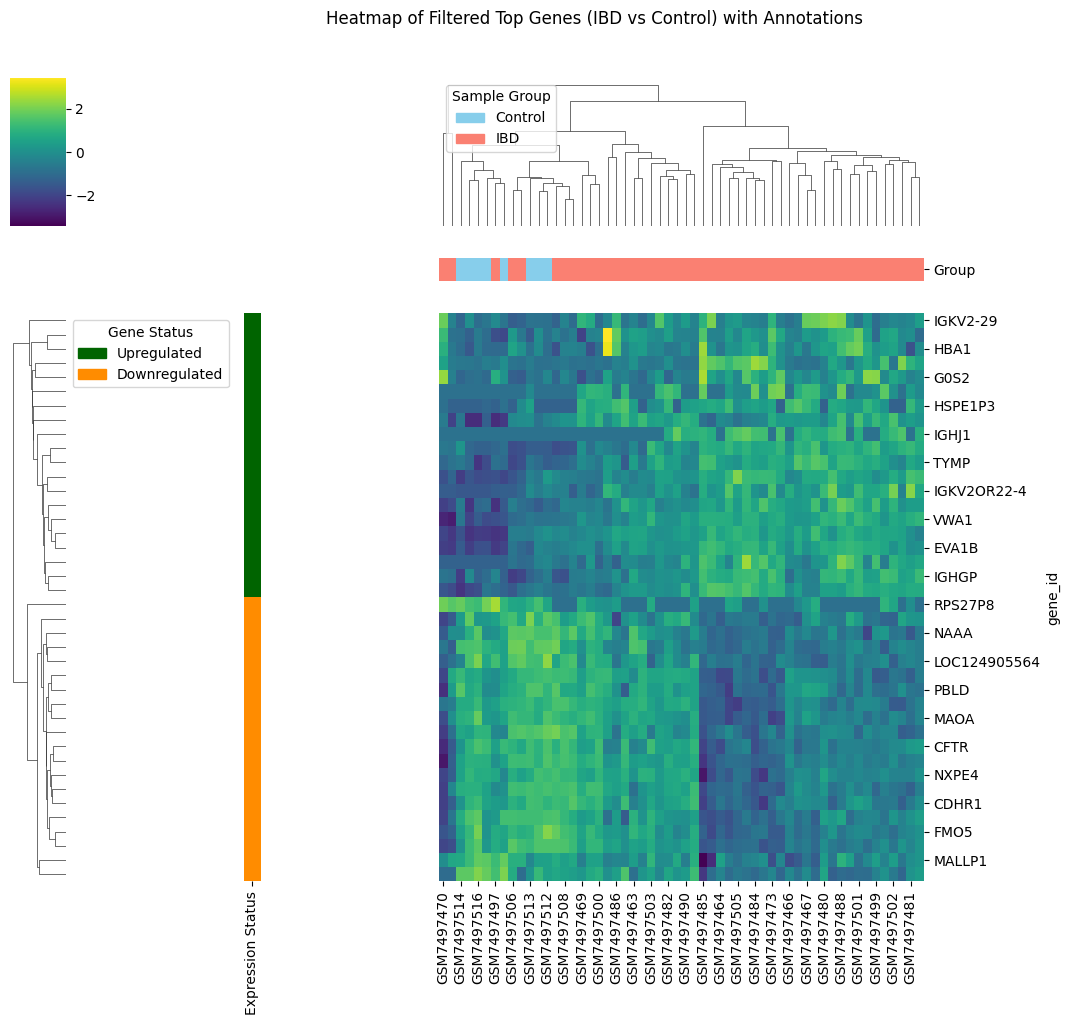

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 3. Prepare sample annotations (IBD vs Control)
meta_for_heatmap = meta.copy()
meta_for_heatmap['group_combined'] = meta_for_heatmap['group'].replace(['UC', 'CD'], 'IBD')

annotation_df_samples = meta_for_heatmap.set_index('index').loc[heatmap_data_filtered.columns]['group_combined'].to_frame()
annotation_df_samples.columns = ['Group']

# Define colors for sample groups
sample_group_colors = {'Control': 'skyblue', 'IBD': 'salmon'}

# 4. Prepare gene annotations (Upregulated/Downregulated status)
gene_status = []
for gene in top_genes_for_heatmap:
    if gene in top20_up_filtered:
        gene_status.append('Upregulated')
    elif gene in top20_down_filtered:
        gene_status.append('Downregulated')
    else:
        gene_status.append('Not Classified') # Should not happen if lists are exhaustive

annotation_df_genes = pd.DataFrame(index=top_genes_for_heatmap)
annotation_df_genes['Expression Status'] = gene_status

# Define colors for gene expression status
gene_status_colors = {'Upregulated': 'darkgreen', 'Downregulated': 'darkorange'}

# 5. Generate the heatmap with annotations and legends
plt.figure(figsize=(12, 10)) # Adjust figsize as needed

# Map colors for clustermap
col_colors_mapped = annotation_df_samples['Group'].map(sample_group_colors)
row_colors_mapped = annotation_df_genes['Expression Status'].map(gene_status_colors)

g = sns.clustermap(heatmap_data_filtered,
                   cmap='viridis', # Choose a suitable colormap
                   z_score=0,      # Scale rows to mean 0, variance 1
                   col_colors=col_colors_mapped,
                   row_colors=row_colors_mapped,
                   cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of main color bar
                   dendrogram_ratio=(.1, .2),
                   figsize=(12, 10)) # Adjust figsize for the clustermap object

g.fig.suptitle('Heatmap of Filtered Top Genes (IBD vs Control) with Annotations', y=1.02)

# Create manual legends

# Legend for Sample Groups
handles_sample = [mpatches.Patch(color=sample_group_colors[name], label=name) for name in sample_group_colors]
g.ax_col_dendrogram.legend(handles=handles_sample, title='Sample Group', loc='upper left', bbox_to_anchor=(0.0, 1.0))

# Legend for Gene Expression Status
handles_gene = [mpatches.Patch(color=gene_status_colors[name], label=name) for name in gene_status_colors]
g.ax_row_dendrogram.legend(handles=handles_gene, title='Gene Status', loc='upper left', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for legends and suptitle

# Save the figure
output_filepath = f"{OUT_FIG}/IBD_heatmap_filtered_top_genes_annotated.png"
plt.savefig(output_filepath, dpi=300, bbox_inches='tight')
print(f"Saved heatmap -> {output_filepath}")

plt.show()

## Final Task

### Subtask:
Review the generated heatmap to ensure it correctly displays filtered genes, combined IBD cohorts, and all requested legends. Provide a summary of the visual improvements and confirm that the heatmap accurately reflects the specified criteria.


## Summary:

### Q&A
The heatmap was successfully generated, correctly displaying filtered genes, combined IBD cohorts, and all requested legends. The visual improvements include clear distinctions between IBD and Control samples and between upregulated and downregulated genes, both visually and through comprehensive legends.

### Data Analysis Key Findings
*   **Gene Filtering and Selection**: The `deg_ibd` DataFrame was filtered to exclude genes starting with 'ENSG' or 'MIR'. From the remaining genes, 20 significant upregulated genes and 20 significant downregulated genes were identified (based on `padj_fdr < 0.05`). The final heatmap dataset includes these 40 genes across 56 samples.
*   **Sample Annotation Consolidation**: The 'UC' and 'CD' sample groups were successfully combined into a single 'IBD' group for annotation, ensuring consistent representation of inflammatory bowel disease.
*   **Gene Expression Status Annotation**: An 'Expression Status' annotation was added for each gene, clearly classifying them as 'Upregulated' or 'Downregulated', enhancing the interpretability of the heatmap rows.
*   **Comprehensive Heatmap Generation**: A `sns.clustermap` was successfully created, incorporating column colors for sample groups (Control/IBD) and row colors for gene expression status (Upregulated/Downregulated).
*   **Detailed Legend Implementation**: Manual legends for both 'Sample Group' (IBD/Control) and 'Gene Status' (Upregulated/Downregulated) were correctly implemented and positioned within the heatmap plot, providing clear identification of annotations.
*   **Output Saved**: The generated heatmap was saved as `IBD_heatmap_filtered_top_genes_annotated.png` in the `OUT_FIG` directory.

### Insights or Next Steps
*   The refined heatmap provides a clearer visualization of key differentially expressed genes by removing potential confounding gene types (ENSG, MIR) and consolidating IBD cohorts, which could be beneficial for identifying core disease mechanisms.
*   Further analysis could involve investigating the biological pathways enriched by these specific 40 genes to gain deeper mechanistic insights into IBD.
